In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as geopd
import matplotlib.pyplot as plt
import subprocess

## Config

In [2]:
DIR = "/home/dy23a.fsu/st/datasets/raw"
DIR = os.path.join(DIR, "SF")
TAXI_FILE = Path(DIR) / "sf_taxi_2023.csv"
BIKE_DIR = Path(DIR) / "bike"

# OD trips are binned by a single timestamp. As in the flow notebook, FLOW_MODE
# selects which leg's time stamps the trip:
#   departure -> pickup/start time   (when the trip leaves the origin)
#   arrival   -> dropoff/end time    (when the trip reaches the destination)
# The origin (O) and destination (D) regions are always the pickup and dropoff
# points respectively, regardless of FLOW_MODE.
FLOW_MODE = "departure"  # departure -> pickup/start ; arrival -> dropoff/end
assert FLOW_MODE in {"arrival", "departure"}

NHOODS_PATH = "./SF Analysis Neighborhoods.geojson"

OUT_DIR = Path(DIR)

# SF has only two mobilities -- taxi (SFMTA) and bike (Bay Wheels) -- and BOTH
# are GPS-based, so both endpoints of every trip are spatially joined to an
# analysis-neighborhood polygon (like DC). Unlike DC's hour-rounded taxi, SF
# taxi timestamps keep full second precision, so the dataset stays on a 15-min
# grid (matching NYC / Chicago). 

# Optional sub-region filter. Set to a list of neighborhood names to keep only
# those (rows AND columns of the OD tensor); leave as None / "all" to keep all.
TARGET_NHOODS = None
TARGET_TAG = "subset"

In [3]:
YEAR = 2023
FREQ = "15min"
TIME_START = pd.Timestamp(f"{YEAR}-01-01 00:00:00")
TIME_END = pd.Timestamp(f"{YEAR + 1}-01-01 00:00:00")
STEPS = pd.date_range(TIME_START, TIME_END, freq=FREQ, inclusive="left")
T = len(STEPS)
FREQ_TAG = FREQ
print(f"YEAR={YEAR}, FREQ={FREQ}, T={T} steps, FLOW_MODE={FLOW_MODE}")

YEAR=2023, FREQ=15min, T=35040 steps, FLOW_MODE=departure


## Shapefile and helpers

Region order follows the shapefile (sorted by `nhood`). Unlike the flow
notebook -- which builds `(N, T)` per region -- an OD matrix is `N x N` per
step. SF has only `N=41` analysis neighborhoods, so the full `(N, N, T)` tensor
is small; we build the **full** OD tensor and apply the optional `TARGET_NHOODS`
filter afterwards (mirroring the flow notebook). All output `(N, N, M, T)`
arrays use the shapefile order (origin axis first, destination second).
Neighborhoods are identified by `nhood`.

In [4]:
nhoods = geopd.read_file(NHOODS_PATH).to_crs("EPSG:4326")
nhoods = nhoods.sort_values("nhood").reset_index(drop=True)
nhoods["region_idx"] = np.arange(len(nhoods), dtype=np.int32)
nhoods_for_join = nhoods[["region_idx", "geometry"]]
N = len(nhoods)
bounds = nhoods.total_bounds
name_to_region = {str(nm): idx for idx, nm in enumerate(nhoods["nhood"].tolist())}
print(f"N={N} analysis neighborhoods, bbox={bounds}")

N=41 analysis neighborhoods, bbox=[-122.51494758   37.708132   -122.35696688   37.83329764]


In [5]:
def make_step_idx_fn(freq, n_t):
    def fn(ts_series, fmt=None):
        ts = pd.to_datetime(ts_series, format=fmt, errors="coerce")
        step = ts.dt.floor(freq)
        delta = (step - TIME_START) / pd.Timedelta(freq)
        idx_float = delta.to_numpy(dtype=np.float64)
        valid = np.isfinite(idx_float) & (idx_float >= 0) & (idx_float < n_t)
        step_idx = np.zeros(len(idx_float), dtype=np.int64)
        step_idx[valid] = idx_float[valid].astype(np.int64)
        return step_idx, valid
    return fn

step_idx_15 = make_step_idx_fn(FREQ, T)

def map_points_to_regions(lon_arr, lat_arr, join_gdf, bounds_):
    minx, miny, maxx, maxy = bounds_
    region_idx = np.full(len(lon_arr), -1, dtype=np.int32)
    in_bbox = (
        (lon_arr >= minx)
        & (lon_arr <= maxx)
        & (lat_arr >= miny)
        & (lat_arr <= maxy)
    )
    if not np.any(in_bbox):
        return region_idx
    candidate_ids = np.where(in_bbox)[0]
    pts = geopd.GeoDataFrame(
        {"row_id": candidate_ids},
        geometry=geopd.points_from_xy(lon_arr[in_bbox], lat_arr[in_bbox]),
        crs="EPSG:4326",
    )
    joined = geopd.sjoin(pts, join_gdf, how="left", predicate="intersects")
    matched = joined.dropna(subset=["region_idx"]).drop_duplicates(subset=["row_id"], keep="first")
    region_idx[matched["row_id"].to_numpy(dtype=np.int64)] = matched["region_idx"].to_numpy(dtype=np.int32)
    return region_idx

def accumulate_od(o_region, d_region, step_idx, time_valid, od_matrix, n_t):
    """Bin trips into an (N, N, n_t) origin-destination matrix (in-place).

    o_region / d_region are shapefile region indices (0..N-1, or -1 to drop).
    A trip is kept only when both endpoints map to a valid region.
    """
    n = od_matrix.shape[0]
    valid = time_valid & (o_region >= 0) & (d_region >= 0)
    if not np.any(valid):
        return 0
    flat_idx = (
        (o_region[valid].astype(np.int64) * n + d_region[valid].astype(np.int64)) * n_t
        + step_idx[valid].astype(np.int64)
    )
    binc = np.bincount(flat_idx, minlength=n * n * n_t)
    od_matrix += binc.reshape(n, n, n_t)
    return int(valid.sum())

## OD binning (gps -> shapefile)

Both SF mobilities are GPS-based, so a single helper spatially joins the origin
and destination points of every trip to neighborhood polygons and bins them
into an `(N, N, T)` tensor. Taxi origin/destination points are
`pickup_location_longitude/latitude` and `dropoff_location_longitude/latitude`;
bike uses `start_lng/lat` and `end_lng/lat`. `FLOW_MODE` only chooses which
timestamp (start vs. end) bins the trip.

In [6]:
def process_gps_od_csv(files, o_lon_c, o_lat_c, d_lon_c, d_lat_c, time_col, n_t,
                       step_idx_fn, dt_fmt=None, chunksize=500_000):
    """OD binning for CSVs whose origin & destination are both lon/lat points."""
    od = np.zeros((N, N, n_t), dtype=np.int64)
    total_rows = 0
    kept_rows = 0
    usecols = [o_lon_c, o_lat_c, d_lon_c, d_lat_c, time_col]
    for fp in files:
        print(f"Processing {fp.name} [O=({o_lon_c},{o_lat_c}), D=({d_lon_c},{d_lat_c}), t={time_col}]")
        reader = pd.read_csv(fp, usecols=usecols, chunksize=chunksize, low_memory=False)
        for chunk in reader:
            total_rows += len(chunk)
            chunk = chunk.dropna(subset=usecols)
            if chunk.empty:
                continue
            o_lon = pd.to_numeric(chunk[o_lon_c], errors="coerce").to_numpy(dtype=np.float64)
            o_lat = pd.to_numeric(chunk[o_lat_c], errors="coerce").to_numpy(dtype=np.float64)
            d_lon = pd.to_numeric(chunk[d_lon_c], errors="coerce").to_numpy(dtype=np.float64)
            d_lat = pd.to_numeric(chunk[d_lat_c], errors="coerce").to_numpy(dtype=np.float64)
            valid_xy = (
                np.isfinite(o_lon) & np.isfinite(o_lat)
                & np.isfinite(d_lon) & np.isfinite(d_lat)
            )
            if not np.any(valid_xy):
                continue
            o_lon, o_lat = o_lon[valid_xy], o_lat[valid_xy]
            d_lon, d_lat = d_lon[valid_xy], d_lat[valid_xy]
            ts = chunk.loc[valid_xy, time_col].reset_index(drop=True)
            o_region = map_points_to_regions(o_lon, o_lat, nhoods_for_join, bounds)
            d_region = map_points_to_regions(d_lon, d_lat, nhoods_for_join, bounds)
            step_idx, time_valid = step_idx_fn(ts, fmt=dt_fmt)
            kept_rows += accumulate_od(o_region, d_region, step_idx, time_valid, od, n_t)
    print(f"Rows seen: {total_rows:,}, kept in OD: {kept_rows:,}")
    return od

## Taxi OD

In [7]:
taxi_time_col = "end_time_local" if FLOW_MODE == "arrival" else "start_time_local"
if not TAXI_FILE.exists():
    raise FileNotFoundError(f"SF taxi file not found: {TAXI_FILE}")
sf_taxi_od = process_gps_od_csv(
    [TAXI_FILE],
    "pickup_location_longitude", "pickup_location_latitude",
    "dropoff_location_longitude", "dropoff_location_latitude",
    taxi_time_col, T, step_idx_15,
)
taxi_out = OUT_DIR / f"sf_taxi_od_{YEAR}_{FREQ_TAG}.npy"
np.save(taxi_out, sf_taxi_od)
print(f"Saved {taxi_out} shape={sf_taxi_od.shape} (O,D,T), total={sf_taxi_od.sum():,}")

Processing sf_taxi_2023.csv [O=(pickup_location_longitude,pickup_location_latitude), D=(dropoff_location_longitude,dropoff_location_latitude), t=start_time_local]
Rows seen: 2,465,619, kept in OD: 1,533,802
Saved /home/dy23a.fsu/st/datasets/raw/SF/sf_taxi_od_2023_15min.npy shape=(41, 41, 35040) (O,D,T), total=1,533,802


## Bike OD (gps -> shapefile)

Bay Wheels CSVs carry station lat/lon for both endpoints. File pattern is
`{YYYYMM}-baywheels-tripdata.csv`. Trips are binned on the same 15-min grid as
taxi; East Bay / San Jose trips outside the SF neighborhoods are dropped.

In [8]:
bike_time_col = "ended_at" if FLOW_MODE == "arrival" else "started_at"
bike_files = sorted(BIKE_DIR.glob(f"{YEAR}??-baywheels-tripdata.csv"))
if not bike_files:
    raise FileNotFoundError(f"No Bay Wheels CSV files found under {BIKE_DIR}")
sf_bike_od = process_gps_od_csv(
    bike_files,
    "start_lng", "start_lat", "end_lng", "end_lat",
    bike_time_col, T, step_idx_15,
)
bike_out = OUT_DIR / f"sf_bike_od_{YEAR}_{FREQ_TAG}.npy"
np.save(bike_out, sf_bike_od)
print(f"Saved {bike_out} shape={sf_bike_od.shape} (O,D,T), total={sf_bike_od.sum():,}")

Processing 202301-baywheels-tripdata.csv [O=(start_lng,start_lat), D=(end_lng,end_lat), t=started_at]
Processing 202302-baywheels-tripdata.csv [O=(start_lng,start_lat), D=(end_lng,end_lat), t=started_at]
Processing 202303-baywheels-tripdata.csv [O=(start_lng,start_lat), D=(end_lng,end_lat), t=started_at]
Processing 202304-baywheels-tripdata.csv [O=(start_lng,start_lat), D=(end_lng,end_lat), t=started_at]
Processing 202305-baywheels-tripdata.csv [O=(start_lng,start_lat), D=(end_lng,end_lat), t=started_at]
Processing 202306-baywheels-tripdata.csv [O=(start_lng,start_lat), D=(end_lng,end_lat), t=started_at]
Processing 202307-baywheels-tripdata.csv [O=(start_lng,start_lat), D=(end_lng,end_lat), t=started_at]
Processing 202308-baywheels-tripdata.csv [O=(start_lng,start_lat), D=(end_lng,end_lat), t=started_at]
Processing 202309-baywheels-tripdata.csv [O=(start_lng,start_lat), D=(end_lng,end_lat), t=started_at]
Processing 202310-baywheels-tripdata.csv [O=(start_lng,start_lat), D=(end_lng,end_

## Summary

In [9]:
def summarize_od(name, arr):
    arr = np.asarray(arr)
    total = float(arr.sum())
    nnz = int(np.count_nonzero(arr))
    density = 100.0 * nnz / arr.size if arr.size else 0.0
    pair_flow = arr.sum(axis=2)                      # (O, D) total over time
    active_pairs = int((pair_flow > 0).sum())
    active_o = int((arr.sum(axis=(1, 2)) > 0).sum())
    active_d = int((arr.sum(axis=(0, 2)) > 0).sum())
    active_steps = int((arr.sum(axis=(0, 1)) > 0).sum())
    print(f"[{name}] shape={arr.shape}, total={total:,.0f}, nnz={nnz:,} ({density:.3f}%), "
          f"active_pairs={active_pairs}/{arr.shape[0] * arr.shape[1]}, "
          f"active_O={active_o}/{arr.shape[0]}, active_D={active_d}/{arr.shape[1]}, "
          f"active_steps={active_steps}/{arr.shape[2]}")

for name, arr in [("taxi", sf_taxi_od), ("bike", sf_bike_od)]:
    summarize_od(name, arr)

[taxi] shape=(41, 41, 35040), total=1,533,802, nnz=1,197,005 (2.032%), active_pairs=1644/1681, active_O=41/41, active_D=41/41, active_steps=35025/35040
[bike] shape=(41, 41, 35040), total=2,320,087, nnz=1,464,415 (2.486%), active_pairs=1349/1681, active_O=39/41, active_D=39/41, active_steps=34652/35040


## Filter by Neighborhood

If `TARGET_NHOODS` is a list of neighborhood names, select the matching rows
**and** columns from each `(N, N, T)` OD tensor, write
`sf_<tag>_<mobility>_od_<year>_<freq>.npy`, and export the filtered region
GeoJSON in the same order. Set `TARGET_NHOODS=None` to keep all 41
neighborhoods.

In [10]:
if TARGET_NHOODS is not None and (not isinstance(TARGET_NHOODS, str) or TARGET_NHOODS.lower() != "all"):
    target_set = {str(c) for c in TARGET_NHOODS}
    mask = nhoods["nhood"].astype(str).isin(target_set)
    sel_idx = np.where(mask.to_numpy())[0]
    if sel_idx.size == 0:
        raise ValueError(f"No neighborhoods matched TARGET_NHOODS={TARGET_NHOODS}")
    nhoods_sel = nhoods.iloc[sel_idx].reset_index(drop=True)
    nhood_tag = TARGET_TAG.lower().replace(" ", "_")
    geo_path = OUT_DIR / f"{nhood_tag}.geojson"
    nhoods_sel.drop(columns=["region_idx"], errors="ignore").to_file(geo_path, driver="GeoJSON")
    print(f"TARGET_NHOODS kept {len(sel_idx)}/{N} neighborhoods -> {geo_path}")
    for name, arr in [("taxi", sf_taxi_od), ("bike", sf_bike_od)]:
        sub = arr[np.ix_(sel_idx, sel_idx)]           # (k, k, T)
        out = OUT_DIR / f"sf_{nhood_tag}_{name}_od_{YEAR}_{FREQ_TAG}.npy"
        np.save(out, sub)
        print(f"  {out} shape={sub.shape}, total={sub.sum():,}")
else:
    sel_idx = np.arange(N)
    nhoods_sel = nhoods.copy()
    nhood_tag = "all"
    print(f"Neighborhood filter disabled, keeping all {N} neighborhoods")

Neighborhood filter disabled, keeping all 41 neighborhoods


## Merge mobilities -> (N, N, M, T)

Stack the two SF mobilities `["taxi", "bike"]` along a new mobility axis to get
the final `(N, N, M, T)` tensor (origin, destination, mobility, time), `M=2`.

In [11]:
MERGE_MOBILITIES = ["taxi", "bike"]
MOBILITY_ARRS = {"taxi": sf_taxi_od, "bike": sf_bike_od}
missing = [m for m in MERGE_MOBILITIES if m not in MOBILITY_ARRS]
if missing:
    raise ValueError(f"Unknown mobilities in MERGE_MOBILITIES: {missing}")

# (O, D, T) per mobility -> stack on axis=2 -> (N, N, M, T)
merged = np.stack([MOBILITY_ARRS[m] for m in MERGE_MOBILITIES], axis=2)
merged_tag = "_".join(MERGE_MOBILITIES)
M_dim = len(MERGE_MOBILITIES)
merged_out = OUT_DIR / f"sf_{merged_tag}_od_{YEAR}_{FREQ_TAG}.npy"
np.save(merged_out, merged)
print(f"{merged_out} shape={merged.shape} (N, N, M, T) with M={M_dim} mobilities")

if TARGET_NHOODS is not None and (not isinstance(TARGET_NHOODS, str) or TARGET_NHOODS.lower() != "all"):
    merged_c = merged[np.ix_(sel_idx, sel_idx)]       # (k, k, M, T)
    merged_c_out = OUT_DIR / f"sf_{nhood_tag}_{merged_tag}_od_{YEAR}_{FREQ_TAG}.npy"
    np.save(merged_c_out, merged_c)
    print(f"{merged_c_out} shape={merged_c.shape} (N, N, M, T)")

for i in MOBILITY_ARRS:
    i_out = OUT_DIR / f"sf_{i}_od_{YEAR}_{FREQ_TAG}.npy"
    np.save(i_out, MOBILITY_ARRS[i])
    print(f"{i_out} shape={MOBILITY_ARRS[i].shape} (N, N, T) with 1 mobilities")

/home/dy23a.fsu/st/datasets/raw/SF/sf_taxi_bike_od_2023_15min.npy shape=(41, 41, 2, 35040) (N, N, M, T) with M=2 mobilities
/home/dy23a.fsu/st/datasets/raw/SF/sf_taxi_od_2023_15min.npy shape=(41, 41, 35040) (N, N, T) with 1 mobilities
/home/dy23a.fsu/st/datasets/raw/SF/sf_bike_od_2023_15min.npy shape=(41, 41, 35040) (N, N, T) with 1 mobilities


## Visualization & Sparsity Report

For each mobility (`taxi`, `bike`):
- **OD heatmap**: log1p total origin-destination flow `(O x D)` over the year.
- **Origin/destination choropleth**: total outflow / inflow per neighborhood.
- **Temporal panels**: daily total OD flow + weekday x hour-of-day occupancy.
- **Sparsity report**: zero-rate over `(O, D, T)`, dead pairs / steps, quantiles.

In [12]:
MOBILITY_VIZ = [("taxi", sf_taxi_od, STEPS), ("bike", sf_bike_od, STEPS)]

def plot_od_heat(arr, title):
    pair = np.asarray(arr).sum(axis=2)              # (O, D)
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    im = ax.imshow(np.log1p(pair), aspect="auto", cmap="magma", origin="upper")
    ax.set_title(title)
    ax.set_xlabel("Destination region (idx)")
    ax.set_ylabel("Origin region (idx)")
    fig.colorbar(im, ax=ax, shrink=0.8, label="log1p(total flow)")
    plt.tight_layout()
    plt.show()

def plot_nhood_heat(gdf, values, title, cmap="YlOrRd", log=True):
    plot_gdf = gdf.copy()
    vals = np.asarray(values, dtype=np.float64)
    plot_gdf["flow"] = np.log1p(vals) if log else vals
    legend_label = "log1p(total flow)" if log else "total flow"
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    plot_gdf.plot(column="flow", cmap=cmap, linewidth=0.2, edgecolor="black",
                  legend=True, legend_kwds={"label": legend_label, "shrink": 0.6}, ax=ax)
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

def sparsity_report(name, arr, time_index):
    arr = np.asarray(arr)
    total_cells = arr.size
    nnz = int(np.count_nonzero(arr))
    zero_rate = 1.0 - nnz / total_cells if total_cells else 0.0
    total_flow = float(arr.sum())
    pair_sum = arr.sum(axis=2).reshape(-1)
    step_sum = arr.sum(axis=(0, 1))
    dead_pairs = int((pair_sum == 0).sum())
    dead_steps = int((step_sum == 0).sum())
    pair_q = np.quantile(pair_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    step_q = np.quantile(step_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    nz_pair_q = np.quantile(pair_sum[pair_sum > 0], [0.25, 0.5, 0.75]) if (pair_sum > 0).any() else np.array([0, 0, 0])
    print(f"=== Sparsity report: {name} ===")
    print(f"  shape={arr.shape}, total_flow={total_flow:,.0f}")
    print(f"  nnz cells={nnz:,}/{total_cells:,}  zero_rate={zero_rate*100:.3f}%")
    print(f"  dead pairs={dead_pairs}/{pair_sum.size}  dead steps={dead_steps}/{arr.shape[2]}")
    print(f"  pair totals  min/Q1/med/Q3/max = {pair_q[0]:,.0f} / {pair_q[1]:,.0f} / {pair_q[2]:,.0f} / {pair_q[3]:,.0f} / {pair_q[4]:,.0f}")
    print(f"  pair totals  (non-zero only) Q1/med/Q3 = {nz_pair_q[0]:,.0f} / {nz_pair_q[1]:,.0f} / {nz_pair_q[2]:,.0f}")
    print(f"  step totals  min/Q1/med/Q3/max = {step_q[0]:,.0f} / {step_q[1]:,.0f} / {step_q[2]:,.0f} / {step_q[3]:,.0f} / {step_q[4]:,.0f}")
    idx_active = np.where(step_sum > 0)[0]
    if idx_active.size:
        print(f"  first_active={pd.Timestamp(time_index[idx_active[0]])}, last_active={pd.Timestamp(time_index[idx_active[-1]])}")

def plot_temporal_panels(name, arr, time_index):
    arr = np.asarray(arr)
    ts = pd.to_datetime(time_index)
    series = pd.Series(arr.sum(axis=(0, 1)), index=ts)
    daily = series.resample("D").sum()
    hod = pd.DataFrame({"flow": series.values}, index=ts)
    hod["dow"] = hod.index.dayofweek
    hod["hour"] = hod.index.hour
    pivot = hod.pivot_table(index="dow", columns="hour", values="flow", aggfunc="sum").reindex(index=range(7), columns=range(24))
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(daily.index, daily.values, linewidth=1.2)
    axes[0].set_title(f"{name} - daily total OD flow")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Daily total flow")
    axes[0].grid(alpha=0.25)
    im = axes[1].imshow(pivot.values, aspect="auto", cmap="viridis", origin="lower")
    axes[1].set_title(f"{name} - weekday x hour total OD flow")
    axes[1].set_xlabel("Hour of day")
    axes[1].set_ylabel("Day of week (0=Mon)")
    axes[1].set_xticks(range(0, 24, 3))
    axes[1].set_yticks(range(7))
    axes[1].set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    fig.colorbar(im, ax=axes[1], shrink=0.8, label="flow")
    plt.tight_layout()
    plt.show()

=== Sparsity report: taxi ===
  shape=(41, 41, 35040), total_flow=1,533,802
  nnz cells=1,197,005/58,902,240  zero_rate=97.968%
  dead pairs=37/1681  dead steps=15/35040
  pair totals  min/Q1/med/Q3/max = 0 / 43 / 192 / 640 / 48,025
  pair totals  (non-zero only) Q1/med/Q3 = 47 / 198 / 658
  step totals  min/Q1/med/Q3/max = 0 / 23 / 39 / 61 / 272
  first_active=2023-01-01 00:00:00, last_active=2023-12-31 23:45:00


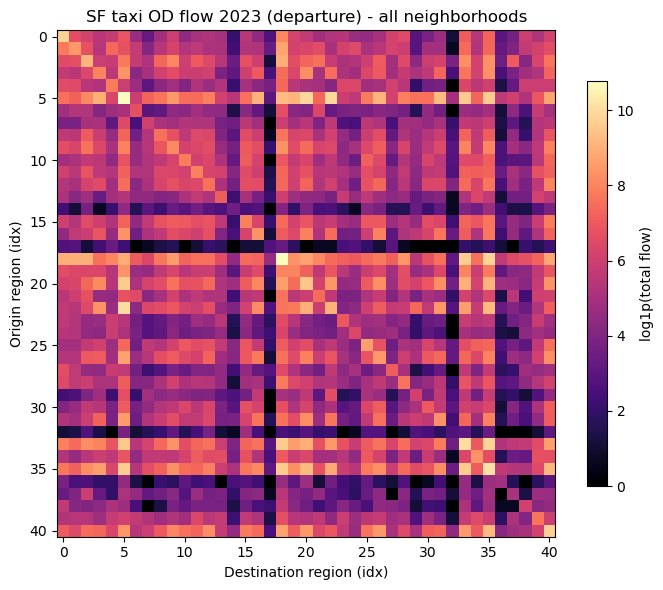

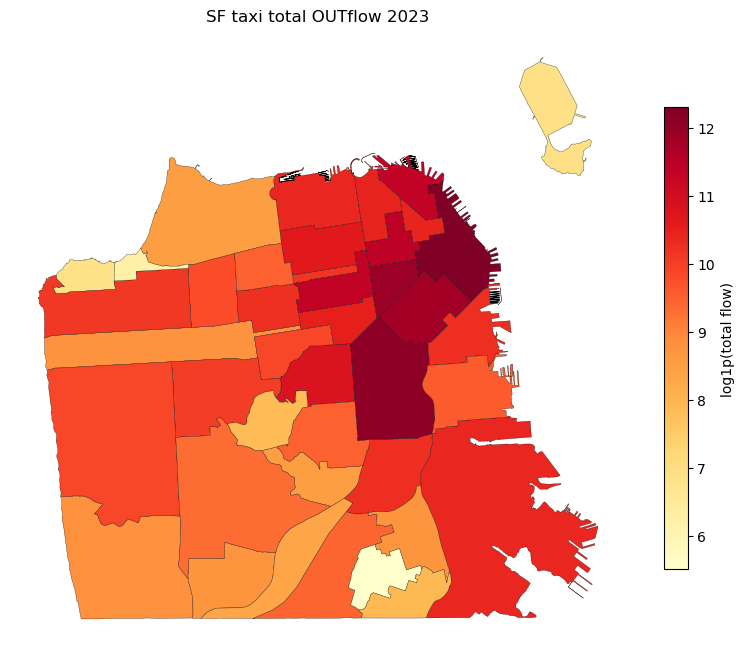

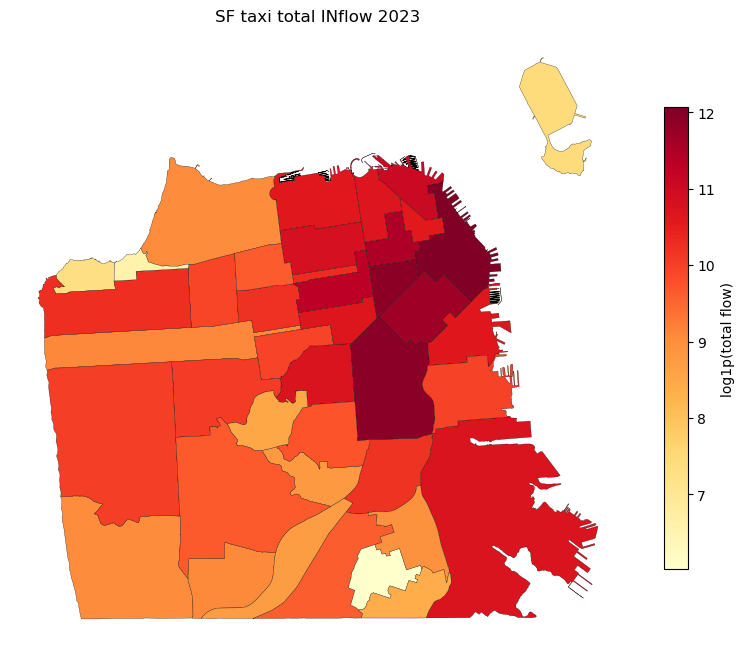

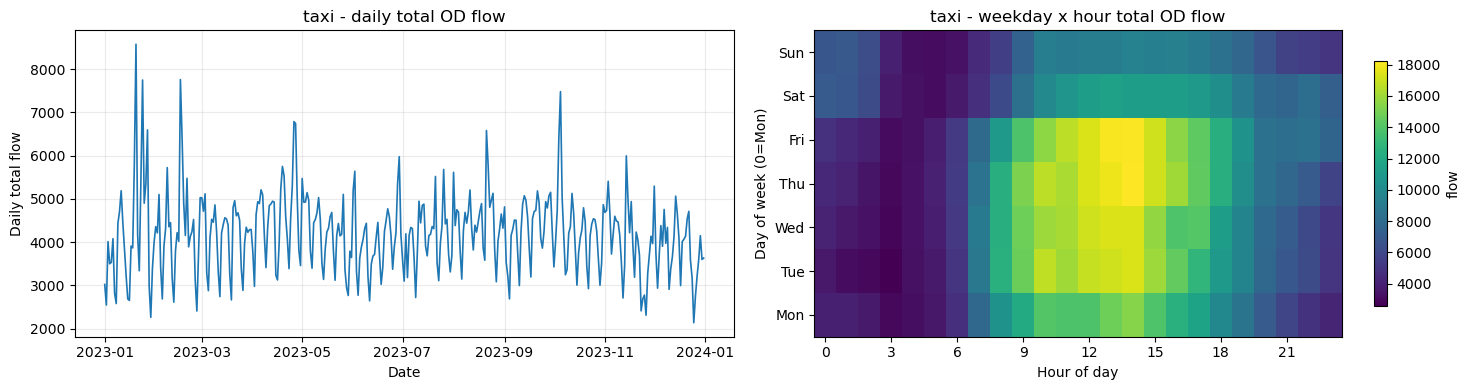

=== Sparsity report: bike ===
  shape=(41, 41, 35040), total_flow=2,320,087
  nnz cells=1,464,415/58,902,240  zero_rate=97.514%
  dead pairs=332/1681  dead steps=388/35040
  pair totals  min/Q1/med/Q3/max = 0 / 2 / 61 / 664 / 149,532
  pair totals  (non-zero only) Q1/med/Q3 = 17 / 188 / 1,016
  step totals  min/Q1/med/Q3/max = 0 / 14 / 57 / 101 / 341
  first_active=2023-01-01 00:00:00, last_active=2023-12-31 23:45:00


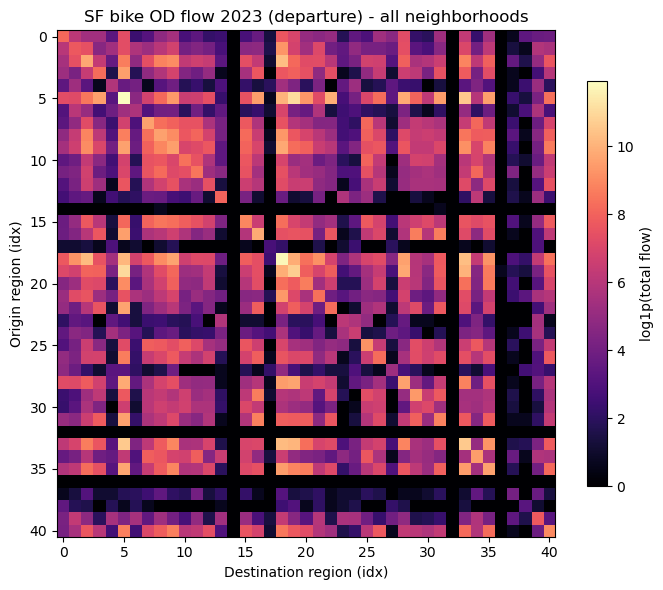

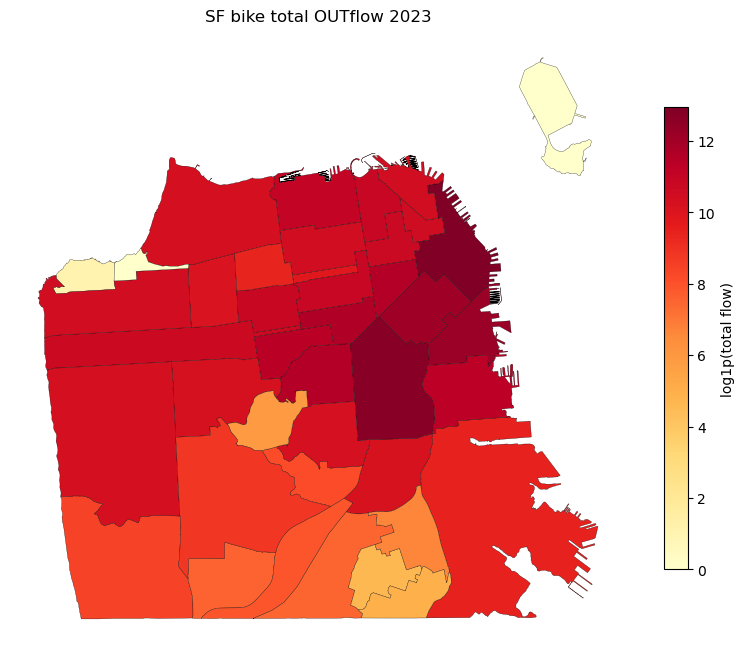

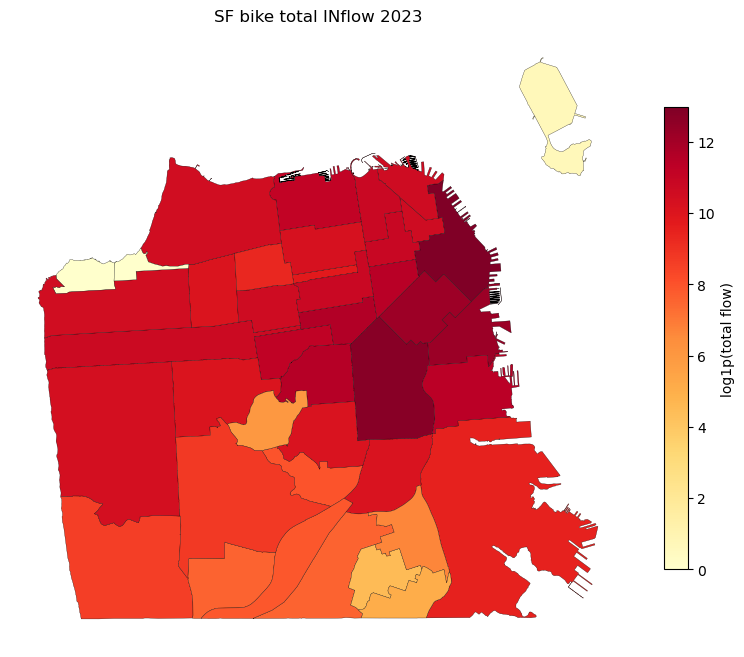

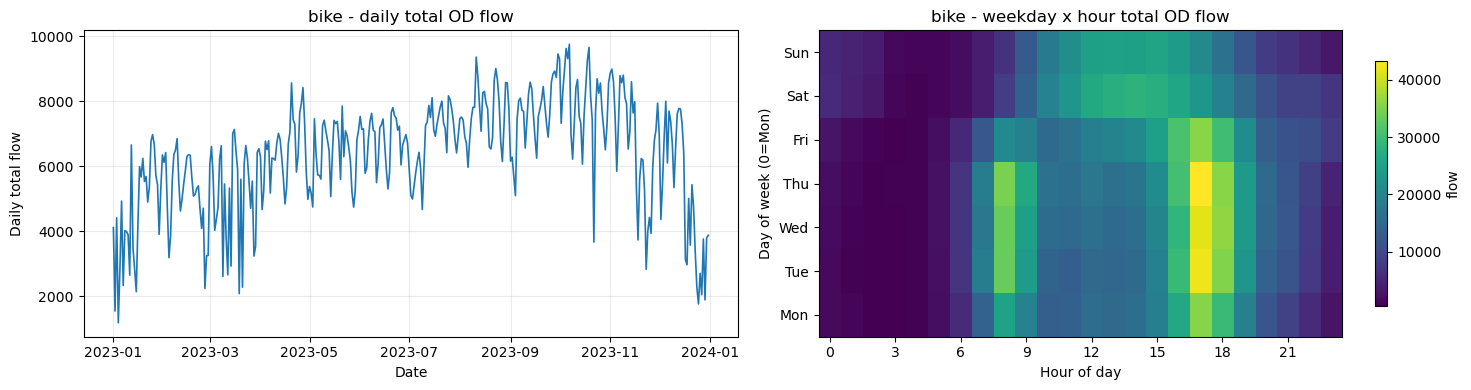

In [13]:
nhood_active = TARGET_NHOODS is not None and (not isinstance(TARGET_NHOODS, str) or TARGET_NHOODS.lower() != "all")
for name, arr, time_index in MOBILITY_VIZ:
    tag = f"{name} [{TARGET_TAG}]" if nhood_active else name
    viz_arr = arr[np.ix_(sel_idx, sel_idx)] if nhood_active else arr
    viz_gdf = nhoods_sel if nhood_active else nhoods
    sparsity_report(tag, viz_arr, time_index)
    plot_od_heat(viz_arr, f"SF {name} OD flow {YEAR} ({FLOW_MODE}) - {TARGET_TAG if nhood_active else 'all neighborhoods'}")
    plot_nhood_heat(viz_gdf, viz_arr.sum(axis=(1, 2)), f"SF {name} total OUTflow {YEAR}")
    plot_nhood_heat(viz_gdf, viz_arr.sum(axis=(0, 2)), f"SF {name} total INflow {YEAR}")
    plot_temporal_panels(name, viz_arr, time_index)

## Generate dataset (NNDT)

Feed the 15-min `(N, N, M, T)` tensor to `utils/generate.py` with `--fmt NNDT`
(origin, destination, mobility, time). The generator reorders to `(T, N, N, M)`,
fits a per-channel log1p MinMaxScaler over the `M` mobility channels, and writes
`his.npz` + `info.json` + `meta.json` + index files.

In [14]:
if TARGET_NHOODS is not None and (not isinstance(TARGET_NHOODS, str) or TARGET_NHOODS.lower() != "all"):
    src_path = OUT_DIR / f"sf_{nhood_tag}_{merged_tag}_od_{YEAR}_{FREQ_TAG}.npy"
    DATASET = f"sf_{nhood_tag}_od_15min"
else:
    src_path = OUT_DIR / f"sf_{merged_tag}_od_{YEAR}_{FREQ_TAG}.npy"
    DATASET = "sf_od_15min"

print(f"Source {src_path} shape={tuple(np.load(src_path, mmap_mode='r').shape)} (N, N, M, T)")

YEAR = 2025 # For convience
for hy in [1, 3, 6, 9, 12]:
    subprocess.run([
        "python3", "/home/dy23a.fsu/st/utils/generate.py",
        "--data_path", str(src_path),
        "--fmt", "NNDT",
        "--clip_neg",
        "--per_channel",
        "--log1p",
        "--dataset", DATASET,
        "--years", f"{YEAR}_12to{hy}",
        "--seq_length_x", "12",
        "--seq_length_y", str(hy),
    ], check=True)

DATASET_list=[]
for i in MOBILITY_ARRS:
    d=DATASET+"_"+i
    DATASET_list.append(d)
    i_out = OUT_DIR / f"sf_{i}_od_{YEAR}_{FREQ_TAG}.npy"
    np.save(i_out, MOBILITY_ARRS[i])
    print(f"{i_out} shape={MOBILITY_ARRS[i].shape} (N, N, T) with 1 mobilities")
    subprocess.run([
        "python3", "/home/dy23a.fsu/st/utils/generate.py",
        "--data_path", str(i_out),
        "--fmt", "NNT",
        "--clip_neg",
        "--per_channel",
        "--log1p",
        "--dataset", d,
        "--years", f"{YEAR}_12to1",
        "--seq_length_x", "12",
        "--seq_length_y", "1",
    ], check=True)

Source /home/dy23a.fsu/st/datasets/raw/SF/sf_taxi_bike_od_2023_15min.npy shape=(41, 41, 2, 35040) (N, N, M, T)
Loaded /home/dy23a.fsu/st/datasets/raw/SF/sf_taxi_bike_od_2023_15min.npy, raw shape: (41, 41, 2, 35040)
Clipped negative values to 0
Reordered NNDT → TNND, shape: (35040, 41, 41, 2)
Raw — max: 176, min: 0, mean: 0.0327, std: 0.2803
Index range: [11, 35039), total=35028, train=28022, val=3503, test=3503
MinMaxScaler(log1p=True) min: [0.0, 0.0], max: [5.176149845123291, 3.9889841079711914]
Normalized — max: 1.0000, min: 0.0000, mean: 0.0043, std: 0.0304
Saved meta.json to /blue/gtyson.fsu/dy23a.fsu/datasets/sf_od_15min/2025_12to1/meta.json
Saved to /blue/gtyson.fsu/dy23a.fsu/datasets/sf_od_15min/2025_12to1
Saved info.json to /blue/gtyson.fsu/dy23a.fsu/datasets/sf_od_15min/2025_12to1/info.json
Loaded /home/dy23a.fsu/st/datasets/raw/SF/sf_taxi_bike_od_2023_15min.npy, raw shape: (41, 41, 2, 35040)
Clipped negative values to 0
Reordered NNDT → TNND, shape: (35040, 41, 41, 2)
Raw — m

## Adjacency

Distance-based adjacency over the selected neighborhood centroids, saved
alongside the OD dataset. Centroids are computed in a projected CRS (EPSG:3310,
California Albers, meters) to avoid the geographic-CRS centroid warning.

In [15]:
sys.path.insert(0, "/home/dy23a.fsu/st/utils")
from get_adj_mat import get_adjacency_matrix

ADJ_DIR = Path("/home/dy23a.fsu/st/datasets") / DATASET
ADJ_DIR.mkdir(parents=True, exist_ok=True)
ADJ_OUT = ADJ_DIR / "sf.npy"
adj_gdf = nhoods_sel if nhood_active else nhoods

ctr = adj_gdf.set_geometry("geometry").to_crs("EPSG:3310").centroid.reset_index(drop=True)
N_adj = len(ctr)
ids = list(range(N_adj))
distance = [[i, j, ctr[i].distance(ctr[j])] for i in ids for j in ids]
adj_mx = get_adjacency_matrix(distance_df=distance, sensor_ids=ids)
np.save(ADJ_OUT, adj_mx)

for i in DATASET_list:
    ADJ_DIR = Path("/home/dy23a.fsu/st/datasets") / i
    ADJ_DIR.mkdir(parents=True, exist_ok=True)
    ADJ_OUT = ADJ_DIR / f"sf.npy"
    np.save(ADJ_OUT, adj_mx)

print(f"Saved {ADJ_OUT} shape={adj_mx.shape}")

Saved /home/dy23a.fsu/st/datasets/sf_od_15min_bike/sf.npy shape=(41, 41)
